# Prompt Analysis

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from underthesea import word_tokenize

In [14]:
PROJECT_DIR = '../../../'
FILE_PATH = 'data/test/R2AIStage1DATA.json'

df = pd.read_json(PROJECT_DIR + FILE_PATH)
print(df.head())

   id                                           question
0   1  Các cơ sở ươm tạo và khu làm việc chung được h...
1   2  Doanh nghiệp nhỏ và vừa được hưởng ưu đãi gì k...
2   3  Nếu công ty giữ bản chính bằng cấp của nhân vi...
3   4  Hộ kinh doanh cần đáp ứng điều kiện gì để được...
4   5  Công ty nhỏ và vừa được hỗ trợ giá thuê mặt bằ...


## 1. General Statistics

In [22]:
print("=== TỔNG QUAN TẬP DỮ LIỆU KIỂM THỬ ===")
total_samples = len(df)
missing_values = df['question'].isnull().sum()

print(f"Tổng số lượng câu hỏi trong Test Set: {total_samples}")
print(f"Số lượng bản ghi bị thiếu (Missing values): {missing_values}")

# Kiểm tra tính duy nhất của ID
is_unique_id = df['id'].is_unique
print(f"Tính toàn vẹn của ID (Unique): {is_unique_id}")

=== TỔNG QUAN TẬP DỮ LIỆU KIỂM THỬ ===
Tổng số lượng câu hỏi trong Test Set: 2000
Số lượng bản ghi bị thiếu (Missing values): 0
Tính toàn vẹn của ID (Unique): True


### 1.2. Length distribution

=== THỐNG KÊ CHIỀU DÀI CÂU HỎI ===

- Theo số lượng ký tự:
count    2000.000000
mean      166.066000
std        73.010458
min        46.000000
25%        99.000000
50%       158.000000
75%       223.000000
max       403.000000
Name: char_len, dtype: float64

- Theo số lượng từ đơn (White-space tokenization):
count    2000.000000
mean       37.791000
std        16.843015
min        10.000000
25%        22.000000
50%        37.000000
75%        52.000000
max        89.000000
Name: word_len, dtype: float64


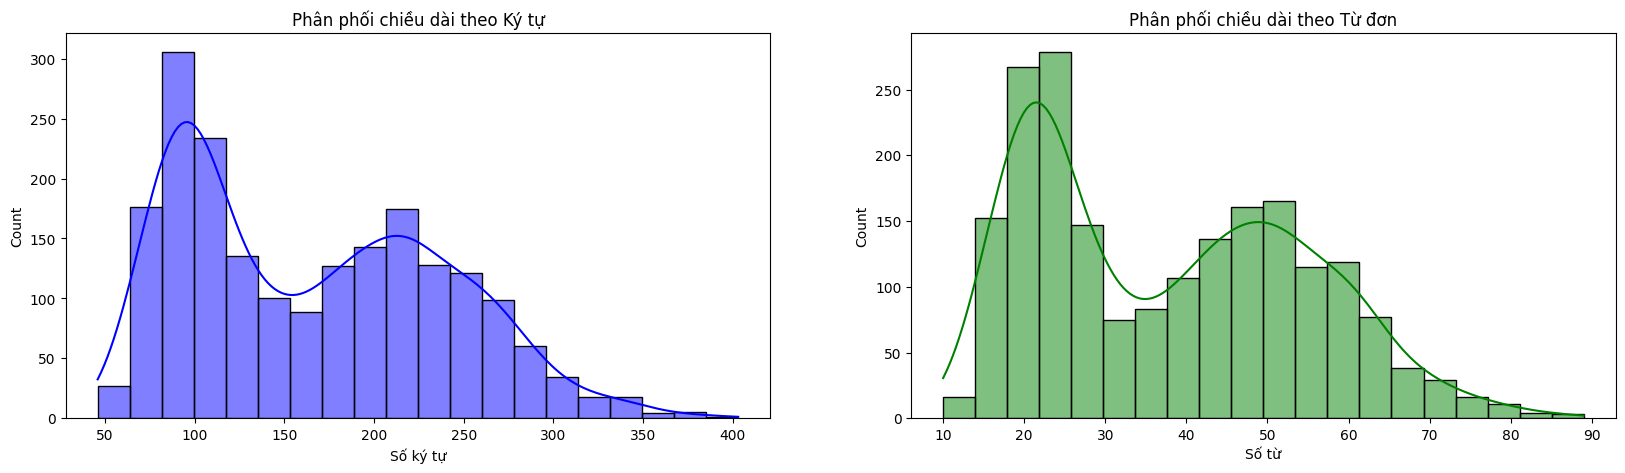

In [28]:
df['char_len'] = df['question'].str.len()
df['word_len'] = df['question'].apply(lambda x: len(x.split()))

print("=== THỐNG KÊ CHIỀU DÀI CÂU HỎI ===")
print("\n- Theo số lượng ký tự:")
print(df['char_len'].describe())

print("\n- Theo số lượng từ đơn (White-space tokenization):")
print(df['word_len'].describe())

# Trực quan hóa phân phối
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.histplot(df['char_len'], bins=20, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Phân phối chiều dài theo Ký tự')
axes[0].set_xlabel('Số ký tự')

sns.histplot(df['word_len'], bins=20, kde=True, ax=axes[1], color='green')
axes[1].set_title('Phân phối chiều dài theo Từ đơn')
axes[1].set_xlabel('Số từ')
plt.show()

## 2. Topic-related analysis

### 2.1. Topic distribution

=== THỐNG KÊ CHI TIẾT 10 PHÂN MẢNG PHÁP LÝ ===
- Thuế & Kế toán doanh nghiệp: Xuất hiện trong 356/2000 câu hỏi (17.80%)
- Hợp đồng lao động & Tiền lương: Xuất hiện trong 361/2000 câu hỏi (18.05%)
- Chế độ Bảo hiểm & Phúc lợi: Xuất hiện trong 105/2000 câu hỏi (5.25%)
- Thành lập & Thay đổi đăng ký: Xuất hiện trong 201/2000 câu hỏi (10.05%)
- Ưu đãi & Hỗ trợ SME: Xuất hiện trong 214/2000 câu hỏi (10.70%)
- Loại hình Hộ kinh doanh: Xuất hiện trong 52/2000 câu hỏi (2.60%)
- Quản trị nội bộ & Đại hội đồng: Xuất hiện trong 69/2000 câu hỏi (3.45%)
- Tái cấu trúc & Giải thể: Xuất hiện trong 81/2000 câu hỏi (4.05%)
- Sở hữu trí tuệ & Thương hiệu: Xuất hiện trong 112/2000 câu hỏi (5.60%)
- Tranh chấp & Xử lý vi phạm: Xuất hiện trong 213/2000 câu hỏi (10.65%)


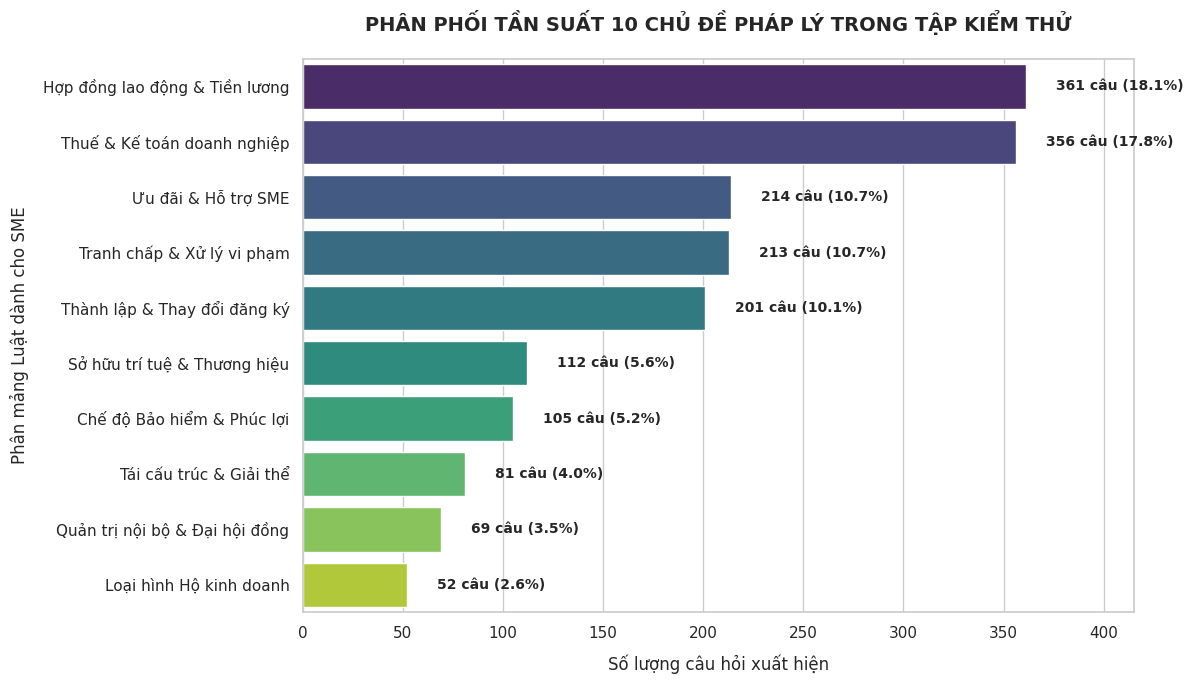

In [61]:
keywords = {
    'Thuế & Kế toán doanh nghiệp': ['thuế', 'tndn', 'gtgt', 'hóa đơn', 'quyết toán', 'lợi nhuận', 'thu nhập doanh nghiệp', 'giá trị gia tăng'],
    'Hợp đồng lao động & Tiền lương': ['nhân viên', 'người lao động', 'lương', 'thử việc', 'sa thải', 'trợ cấp', 'nghỉ việc'],
    'Chế độ Bảo hiểm & Phúc lợi': ['bảo hiểm', 'bhxh', 'bhyt', 'bhtn', 'thai sản', 'tai nạn lao động', 'ốm đau'],
    'Thành lập & Thay đổi đăng ký': ['thành lập', 'đăng ký kinh doanh', 'vốn điều lệ', 'ngành nghề', 'thay đổi đăng ký', 'góp vốn', 'cổ đông', 'thành viên'],
    'Ưu đãi & Hỗ trợ SME': ['sme', 'nhỏ và vừa', 'ươm tạo', 'ưu đãi', 'hỗ trợ', 'mặt bằng', 'quỹ hỗ trợ'],
    'Loại hình Hộ kinh doanh': ['hộ kinh doanh', 'cá thể', 'đăng ký hộ kinh doanh'],
    'Quản trị nội bộ & Đại hội đồng': ['điều lệ', 'đại hội đồng', 'hội đồng quản trị', 'giám đốc', 'đại diện pháp luật', 'nghị quyết', 'biên bản'],
    'Tái cấu trúc & Giải thể': ['giải thể', 'phá sản', 'tạm ngừng', 'tạm dừng', 'sáp nhập', 'chia tách', 'chuyển đổi loại hình'],
    'Sở hữu trí tuệ & Thương hiệu': ['sở hữu trí tuệ', 'thương hiệu', 'nhãn hiệu', 'bản quyền', 'sáng chế', 'bí mật kinh doanh'],
    'Tranh chấp & Xử lý vi phạm': ['tranh chấp', 'khởi kiện', 'tòa án', 'trọng tài', 'bị phạt', 'vi phạm', 'xử phạt hành chính']
}

total_samples = len(df)
domain_counts = {}
domain_percentages = {}

print("=== THỐNG KÊ CHI TIẾT 10 PHÂN MẢNG PHÁP LÝ ===")
for domain, kw_list in keywords.items():
  pattern = '|'.join(kw_list)
  count = df['question'].str.contains(pattern, case=False, na=False).sum()
  percentage = (count / total_samples) * 100

  domain_counts[domain] = count
  domain_percentages[domain] = percentage
  print(f"- {domain}: Xuất hiện trong {count}/{total_samples} câu hỏi ({percentage:.2f}%)")

plot_df = pd.DataFrame({
    'Chủ đề pháp lý': list(domain_counts.keys()),
    'Số lượng câu hỏi': list(domain_counts.values()),
    'Tỷ lệ (%)': list(domain_percentages.values())
}).sort_values(by='Số lượng câu hỏi', ascending=False)

plt.figure(figsize=(12, 7))
sns.set_theme(style='whitegrid')

ax = sns.barplot(
    x='Số lượng câu hỏi',
    y='Chủ đề pháp lý',
    data=plot_df,
    palette='viridis',
    hue='Chủ đề pháp lý',
    legend=False,
)

for i, p in enumerate(ax.patches):
  width = p.get_width()
  percentage = plot_df.iloc[i]['Tỷ lệ (%)']
  ax.text(
      width + 15,
      p.get_y() + p.get_height() / 2,
      f'{int(width)} câu ({percentage:.1f}%)',
      va='center',
      ha='left',
      fontsize=10,
      fontweight='bold',
  )

plt.title('PHÂN PHỐI TẦN SUẤT 10 CHỦ ĐỀ PHÁP LÝ TRONG TẬP KIỂM THỬ', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Số lượng câu hỏi xuất hiện', fontsize=12, labelpad=10)
plt.ylabel('Phân mảng Luật dành cho SME', fontsize=12, labelpad=10)
plt.xlim(0, max(domain_counts.values()) * 1.15)

plt.tight_layout()
plt.show()

### 2.2. User's intention distribution

=== PHÂN TÍCH CHI TIẾT 10 Ý ĐỊNH CỦA CÂU HỎI (INTENT) ===
- Hỏi Điều kiện / Tiêu chí: 100/2000 câu (5.00%)
- Hỏi Thủ tục / Trình tự: 153/2000 câu (7.65%)
- Hỏi Định lượng / Con số: 232/2000 câu (11.60%)
- Hỏi Chế tài / Xử phạt: 163/2000 câu (8.15%)
- Hỏi Quyền lợi / Hỗ trợ: 123/2000 câu (6.15%)
- Hỏi Thẩm quyền giải quyết: 45/2000 câu (2.25%)
- Hỏi Xác nhận / Có-Không: 7/2000 câu (0.35%)
- Hỏi Trách nhiệm / Nghĩa vụ: 113/2000 câu (5.65%)
- Hỏi Thời hạn / Hiệu lực: 218/2000 câu (10.90%)
- Hỏi Rủi ro / Tranh chấp: 241/2000 câu (12.05%)


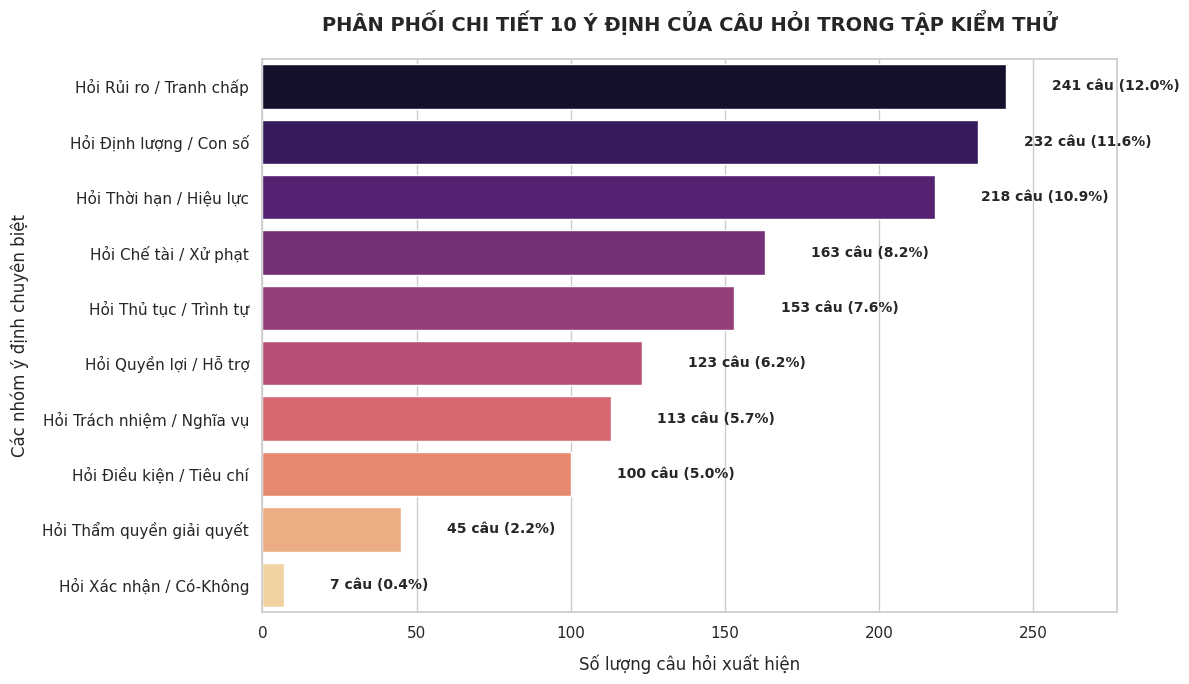

In [62]:

intents = {
    'Hỏi Điều kiện / Tiêu chí': ['điều kiện gì', 'phải đáp ứng', 'tiêu chuẩn nào', 'đối tượng nào'],
    'Hỏi Thủ tục / Trình tự': ['thủ tục', 'trình tự', 'các bước', 'hồ sơ gồm', 'cần chuẩn bị gì'],
    'Hỏi Định lượng / Con số': ['bao nhiêu', 'mấy năm', 'mức nào', 'bao lâu', 'mấy tháng', 'tối đa', 'tối thiểu'],
    'Hỏi Chế tài / Xử phạt': ['bị phạt', 'bị xử lý', 'chế tài', 'tước quyền', 'bị tịch thu'],
    'Hỏi Quyền lợi / Hỗ trợ': ['được hưởng', 'ưu đãi gì', 'được hỗ trợ', 'được miễn', 'được giảm'],
    'Hỏi Thẩm quyền giải quyết': ['cơ quan nào', 'ai có thẩm quyền', 'nộp ở đâu', 'xin cấp ở đâu'],
    'Hỏi Xác nhận / Có-Không': ['có được không', 'có phải là', 'được phép không', 'hợp pháp không'],
    'Hỏi Trách nhiệm / Nghĩa vụ': ['phải làm gì', 'có trách nhiệm', 'có nghĩa vụ', 'bắt buộc phải'],
    'Hỏi Thời hạn / Hiệu lực': ['thời hạn', 'hiệu lực', 'khi nào hết hạn', 'trong vòng bao lâu'],
    'Hỏi Rủi ro / Tranh chấp': ['rủi ro', 'tranh chấp', 'khởi kiện', 'giữ bản chính', 'vi phạm']
}

# ==============================================================
# Tính toán số lượng và tỷ lệ phần trăm
# ==============================================================
total_samples = len(df)
intent_counts = {}
intent_percentages = {}

print("=== PHÂN TÍCH CHI TIẾT 10 Ý ĐỊNH CỦA CÂU HỎI (INTENT) ===")
for intent_name, patterns in intents.items():
    pattern = '|'.join(patterns)
    count = df['question'].str.contains(pattern, case=False, na=False).sum()
    percentage = (count / total_samples) * 100
    
    intent_counts[intent_name] = count
    intent_percentages[intent_name] = percentage
    print(f"- {intent_name}: {count}/{total_samples} câu ({percentage:.2f}%)")


# ==============================================================
# Trực quan hóa dữ liệu bằng biểu đồ thanh ngang
# ==============================================================
plot_intent_df = pd.DataFrame({
    'Ý định câu hỏi': list(intent_counts.keys()),
    'Số lượng câu hỏi': list(intent_counts.values()),
    'Tỷ lệ (%)': list(intent_percentages.values())
}).sort_values(by='Số lượng câu hỏi', ascending=False)

plt.figure(figsize=(12, 7))
sns.set_theme(style='whitegrid')

ax = sns.barplot(
    x='Số lượng câu hỏi',
    y='Ý định câu hỏi',
    data=plot_intent_df,
    palette='magma',
    hue='Ý định câu hỏi',
    legend=False,
)

for i, p in enumerate(ax.patches):
    width = p.get_width()
    percentage = plot_intent_df.iloc[i]['Tỷ lệ (%)']
    ax.text(
        width + 15,
        p.get_y() + p.get_height() / 2,
        f'{int(width)} câu ({percentage:.1f}%)',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
    )

plt.title('PHÂN PHỐI CHI TIẾT 10 Ý ĐỊNH CỦA CÂU HỎI TRONG TẬP KIỂM THỬ', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Số lượng câu hỏi xuất hiện', fontsize=12, labelpad=10)
plt.ylabel('Các nhóm ý định chuyên biệt', fontsize=12, labelpad=10)
plt.xlim(0, max(intent_counts.values()) * 1.15)

plt.tight_layout()
plt.show()

## 3. N-gram analysis

In [52]:
# Cell 9: Generalized N-gram Analysis & Visualization Function (Updated with Document Frequency)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from underthesea import word_tokenize


def analyze_ngram(df, n=1, top_k_table=100, top_k_plot=20, palette='crest'):
  """Hàm tổng quát phân tích tần suất, mật độ (%) và trực quan hóa N-gram.

  Có bổ sung tỷ lệ xuất hiện trên tổng số lượng câu hỏi (Document Frequency %).
  """
  label_dict = {1: 'One-gram', 2: 'Bi-gram', 3: 'Tri-gram'}
  label = label_dict.get(n, f'{n}-gram')

  # 1. Khởi tạo trường tokenized_question nếu chưa có sẵn
  if 'tokenized_question' not in df.columns:
    print(
        "Chạy Tokenization trên toàn bộ Test Set (Quá trình này có thể mất vài"
        " giây)..."
    )

    def stop_word_and_tokenize(text):
      return word_tokenize(text, format='text')

    df['tokenized_question'] = df['question'].apply(stop_word_and_tokenize)

  total_questions = len(df)  # Tổng số lượng câu hỏi để tính tỷ lệ phủ

  # 2. Tính tổng số lượng TẤT CẢ các cụm từ thuộc loại n-gram này trong CSDL
  vectorizer_all = CountVectorizer(ngram_range=(n, n))
  count_matrix_all = vectorizer_all.fit_transform(df['tokenized_question'])
  total_ngrams_count = count_matrix_all.sum()

  # 3. Trích xuất các cụm từ phổ biến nhất theo giới hạn bảng
  vectorizer_top = CountVectorizer(ngram_range=(n, n), max_features=top_k_table)
  count_matrix_top = vectorizer_top.fit_transform(df['tokenized_question'])
  frequencies = dict(
      zip(
          vectorizer_top.get_feature_names_out(),
          count_matrix_top.sum(axis=0).tolist()[0],
      )
  )

  # Sắp xếp kết quả giảm dần theo tần suất
  sorted_freq = sorted(frequencies.items(), key=lambda x: x[1], reverse=True)

  # 4. Quy đổi sang thang đo Mật độ (%), Tỷ lệ câu hỏi (%) và đóng gói DataFrame
  ngram_data = []
  for word, count in sorted_freq:
    density = (count / total_ngrams_count) * 100

    # Tính số câu hỏi thực tế có chứa cụm từ này (Document Frequency)
    # Dùng regex \b để bắt chính xác ranh giới từ/cụm từ, tránh nuốt từ con
    import re

    escaped_word = re.escape(word.replace('_', ' '))
    pattern = rf'\b{escaped_word}\b'
    q_count = (
        df['question'].str.contains(pattern, case=False, na=False, regex=True).sum()
    )
    q_percentage = (q_count / total_questions) * 100

    ngram_data.append({
        f'Cụm từ ({label})': word,
        'Tần suất xuất hiện': count,
        'Mật độ (%)': density,
        'Tỷ lệ trên câu hỏi (%)': q_percentage,
    })

  ngram_df = pd.DataFrame(ngram_data)
  ngram_df.index = ngram_df.index + 1

  # 5. In báo cáo bảng text dạng sạch kèm 2 loại tỷ lệ
  print(
      f"\n=== BẢNG THỐNG KÊ TOP {top_k_table} {label.upper()} KÈM MẬT ĐỘ & TỶ LỆ"
      " PHỦ ==="
  )
  print(ngram_df.to_string())

  # 6. Trực quan hóa Top K cụm từ có mật độ cao nhất bằng biểu đồ thanh ngang
  plot_df = ngram_df.head(top_k_plot)

  plt.figure(figsize=(13, 8))
  sns.set_theme(style='whitegrid')

  ax = sns.barplot(
      x='Mật độ (%)',
      y=f'Cụm từ ({label})',
      data=plot_df,
      palette=palette,
      hue=f'Cụm từ ({label})',
      legend=False,
  )

  # Thêm nhãn số liệu đầy đủ thông tin trực tiếp lên các thanh biểu đồ
  for i, p in enumerate(ax.patches):
    width = p.get_width()
    count_val = plot_df.iloc[i]['Tần suất xuất hiện']
    q_perc_val = plot_df.iloc[i]['Tỷ lệ trên câu hỏi (%)']
    # Format hiển thị: [Số lần] lần (Mật độ % | Xuất hiện ở % số câu hỏi)
    ax.text(
        width + (max(plot_df['Mật độ (%)']) * 0.01),
        p.get_y() + p.get_height() / 2,
        f'{int(count_val)} lần (Mật độ: {width:.2f}% | Phủ: {q_perc_val:.1f}%'
        ' câu hỏi)',
        va='center',
        ha='left',
        fontsize=9.5,
        fontweight='bold',
    )

  plt.title(
      f'TOP {top_k_plot} {label.upper()} CÓ MẬT ĐỘ XUẤT HIỆN CAO NHẤT',
      fontsize=14,
      fontweight='bold',
      pad=20,
  )
  plt.xlabel(
      f'Mật độ xuất hiện (%) trên tổng lượng {label.lower()}',
      fontsize=12,
      labelpad=10,
  )
  plt.ylabel(label, fontsize=12, labelpad=10)
  plt.xlim(0, max(plot_df['Mật độ (%)']) * 1.45)  # Nới rộng trục X để vừa text

  plt.tight_layout()
  plt.show()

### 3.1. One-gram distribution


=== BẢNG THỐNG KÊ TOP 100 ONE-GRAM KÈM MẬT ĐỘ & TỶ LỆ PHỦ ===
    Cụm từ (One-gram)  Tần suất xuất hiện  Mật độ (%)  Tỷ lệ trên câu hỏi (%)
1             công_ty                1787    3.469903                   68.00
2                  và                1598    3.102913                   58.90
3                 thì                 977    1.897087                   45.55
4                được                 908    1.763107                   39.20
5                 khi                 776    1.506796                   36.85
6                  có                 762    1.479612                   37.55
7                 cho                 715    1.388350                   31.20
8                 cần                 686    1.332039                   33.55
9               những                 683    1.326214                   33.00
10              không                 664    1.289320                   30.25
11                nào                 627    1.217476                   63.25
1

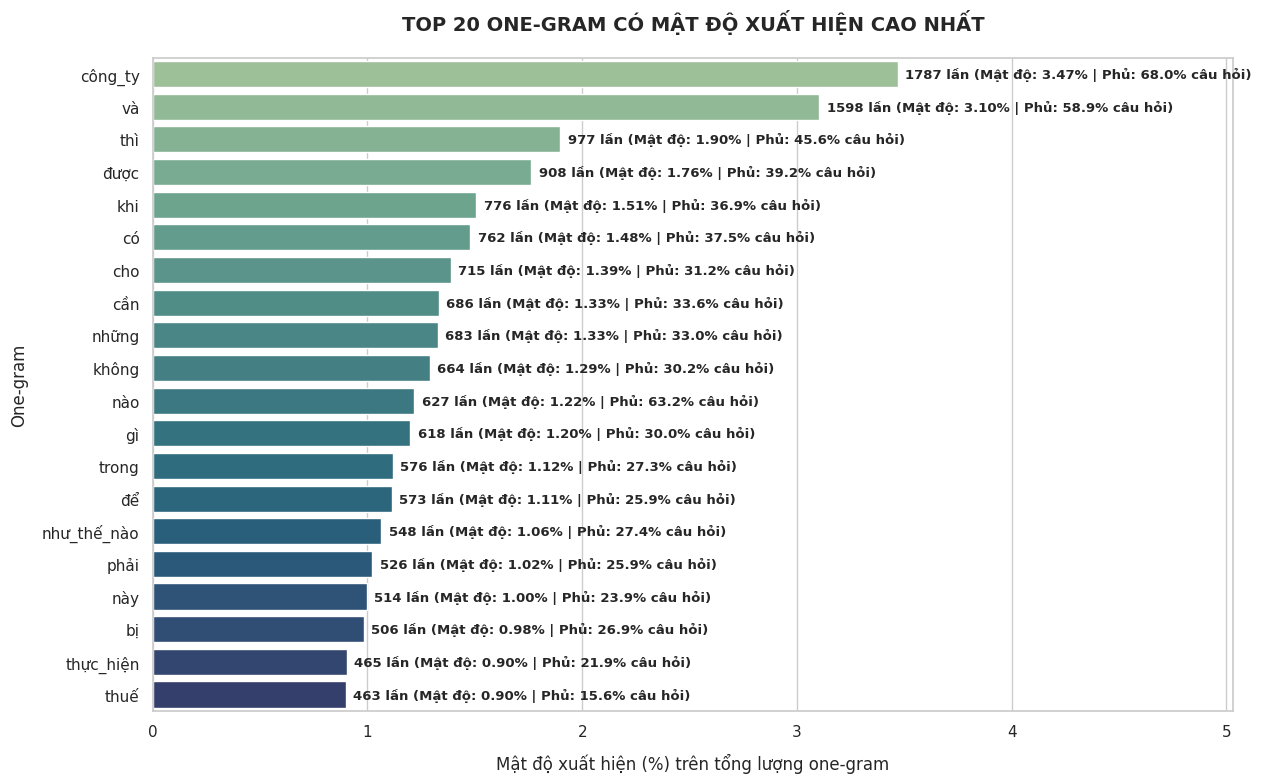

In [53]:
analyze_ngram(df, n=1, palette='crest')

### 3.2. Bi-gram distribution


=== BẢNG THỐNG KÊ TOP 100 BI-GRAM KÈM MẬT ĐỘ & TỶ LỆ PHỦ ===
          Cụm từ (Bi-gram)  Tần suất xuất hiện  Mật độ (%)  Tỷ lệ trên câu hỏi (%)
1              công_ty cần                 277    0.559596                   13.85
2                   ra sao                 274    0.553535                   13.70
3              công_ty tôi                 248    0.501010                   11.85
4              khi công_ty                 206    0.416162                   10.30
5         trong trường_hợp                 189    0.381818                    9.45
6                    sẽ bị                 164    0.331313                    8.15
7              nếu công_ty                 161    0.325253                    8.05
8                  thì cần                 138    0.278788                    6.85
9                 bị xử_lý                 133    0.268687                    6.70
10                hàng hóa                 133    0.268687                    5.90
11          như_thế_nào v

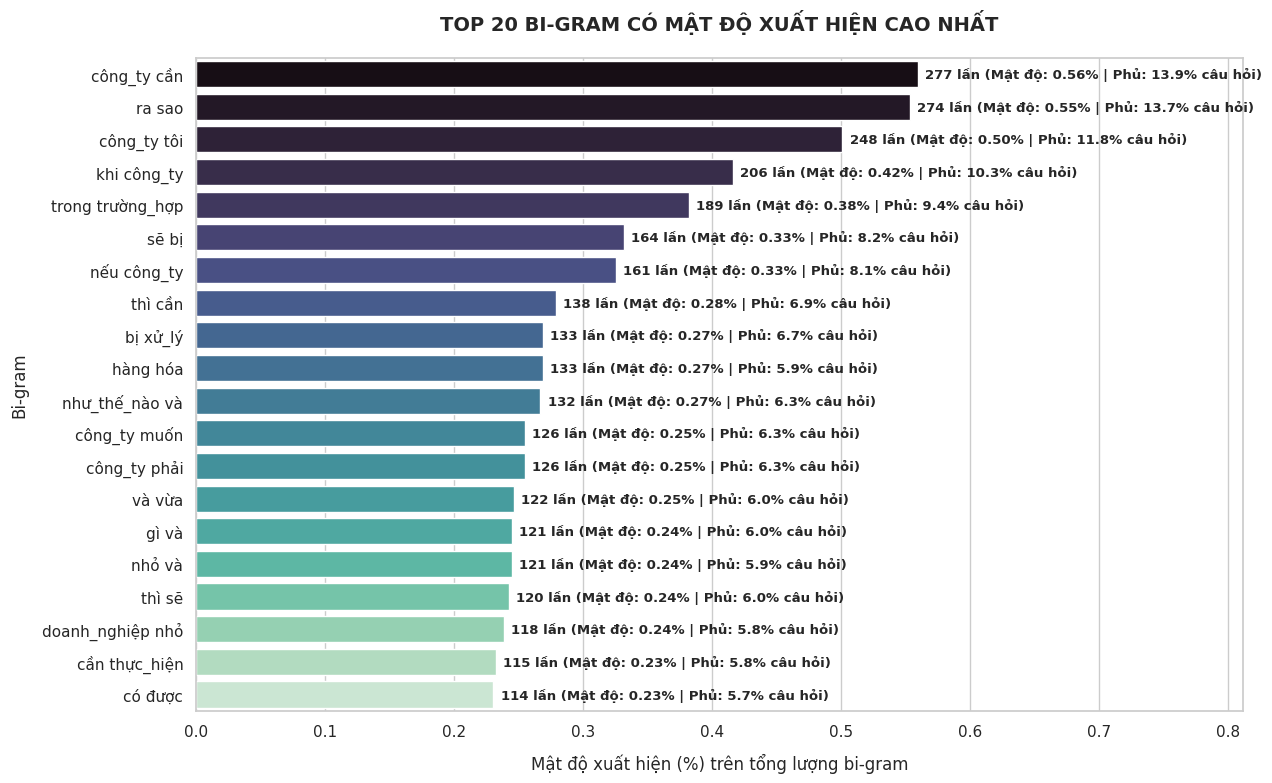

In [54]:
analyze_ngram(df, n=2, palette='mako')

### 3.2. Tri-gram distribution


=== BẢNG THỐNG KÊ TOP 100 TRI-GRAM KÈM MẬT ĐỘ & TỶ LỆ PHỦ ===
                   Cụm từ (Tri-gram)  Tần suất xuất hiện  Mật độ (%)  Tỷ lệ trên câu hỏi (%)
1                        sẽ bị xử_lý                 120    0.252632                    6.00
2                         nhỏ và vừa                 119    0.250526                    5.90
3                doanh_nghiệp nhỏ và                 110    0.231579                    5.35
4                          thì sẽ bị                 103    0.216842                    5.15
5           trong trường_hợp công_ty                  65    0.136842                    3.25
6              công_ty cần thực_hiện                  62    0.130526                    3.10
7                   công_ty tôi muốn                  59    0.124211                    2.95
8                người đại_diện theo                  58    0.122105                    2.60
9                   những giấy_tờ gì                  55    0.115789                    2.75
10     

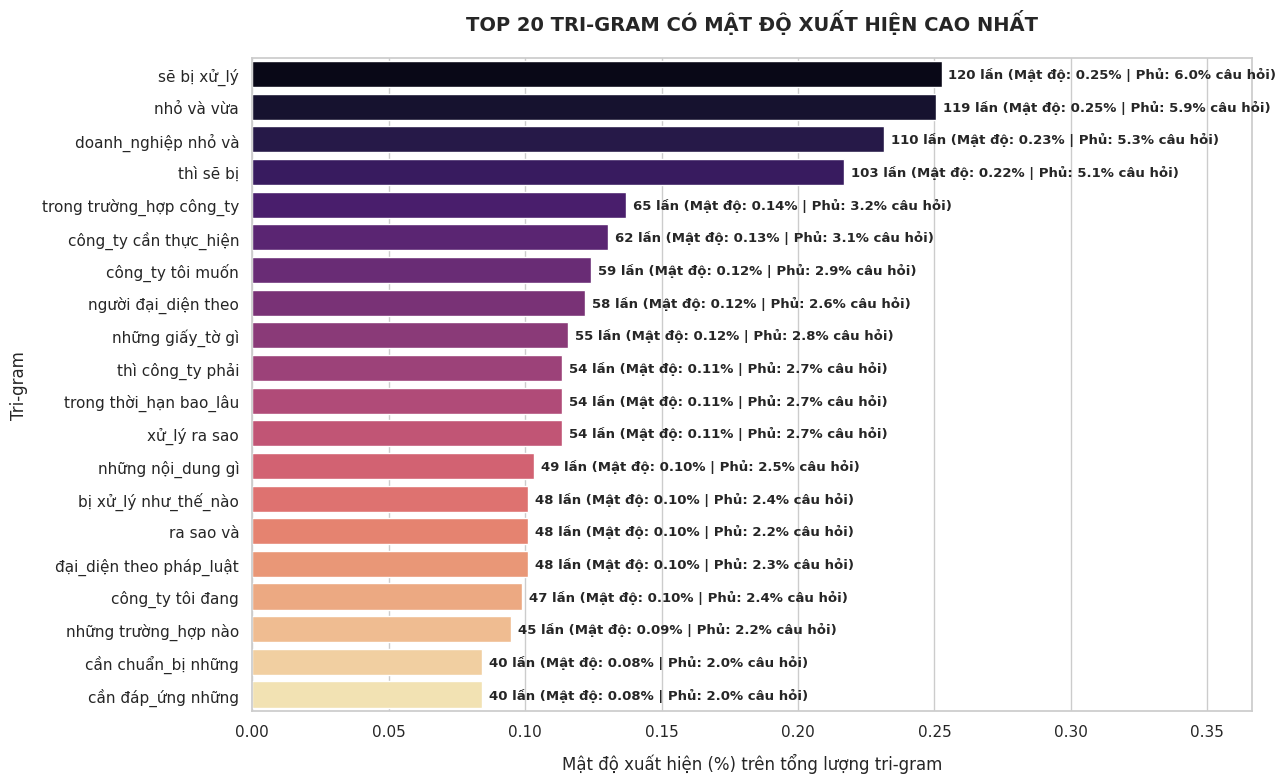

In [55]:
analyze_ngram(df, n=3, palette='magma')

### 3.4. Other n-grams


=== BẢNG THỐNG KÊ TOP 100 4-GRAM KÈM MẬT ĐỘ & TỶ LỆ PHỦ ===
                          Cụm từ (4-gram)  Tần suất xuất hiện  Mật độ (%)  Tỷ lệ trên câu hỏi (%)
1                 doanh_nghiệp nhỏ và vừa                 108    0.237363                    5.35
2                         thì sẽ bị xử_lý                  87    0.191209                    4.35
3           người đại_diện theo pháp_luật                  48    0.105495                    2.30
4                 sẽ bị xử_lý như_thế_nào                  47    0.103297                    2.35
5              trong những trường_hợp nào                  30    0.065934                    1.50
6                 bị xử_lý như_thế_nào và                  28    0.061538                    1.40
7                         bị xử_lý ra sao                  25    0.054945                    1.25
8             công_ty tôi là doanh_nghiệp                  25    0.054945                    1.25
9             cần đáp_ứng những điều_kiện                

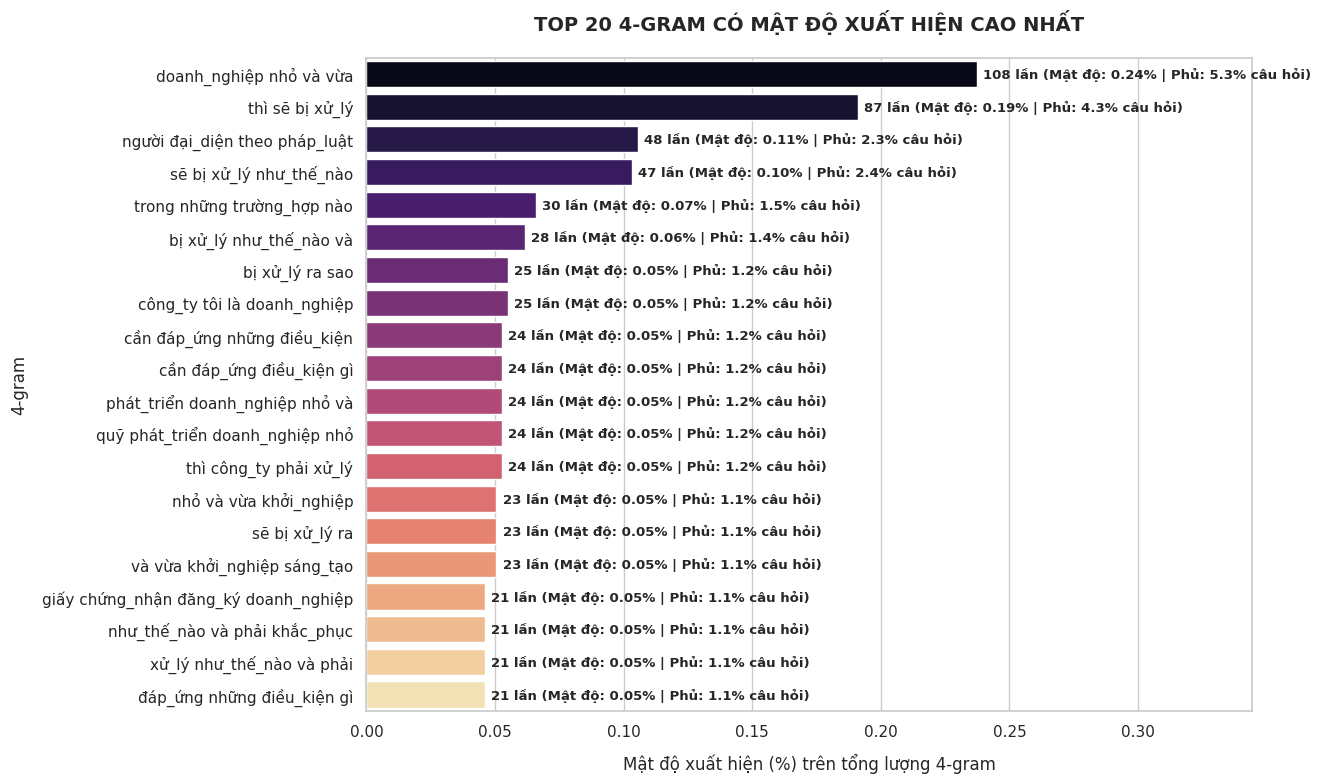


=== BẢNG THỐNG KÊ TOP 100 5-GRAM KÈM MẬT ĐỘ & TỶ LỆ PHỦ ===
                                  Cụm từ (5-gram)  Tần suất xuất hiện  Mật độ (%)  Tỷ lệ trên câu hỏi (%)
1                     thì sẽ bị xử_lý như_thế_nào                  40    0.091954                    2.00
2                      sẽ bị xử_lý như_thế_nào và                  28    0.064368                    1.40
3              phát_triển doanh_nghiệp nhỏ và vừa                  24    0.055172                    1.20
4              quỹ phát_triển doanh_nghiệp nhỏ và                  24    0.055172                    1.20
5             doanh_nghiệp nhỏ và vừa khởi_nghiệp                  23    0.052874                    1.15
6                 nhỏ và vừa khởi_nghiệp sáng_tạo                  23    0.052874                    1.15
7                              sẽ bị xử_lý ra sao                  23    0.052874                    1.15
8                    bị xử_lý như_thế_nào và phải                  21    0.048276          

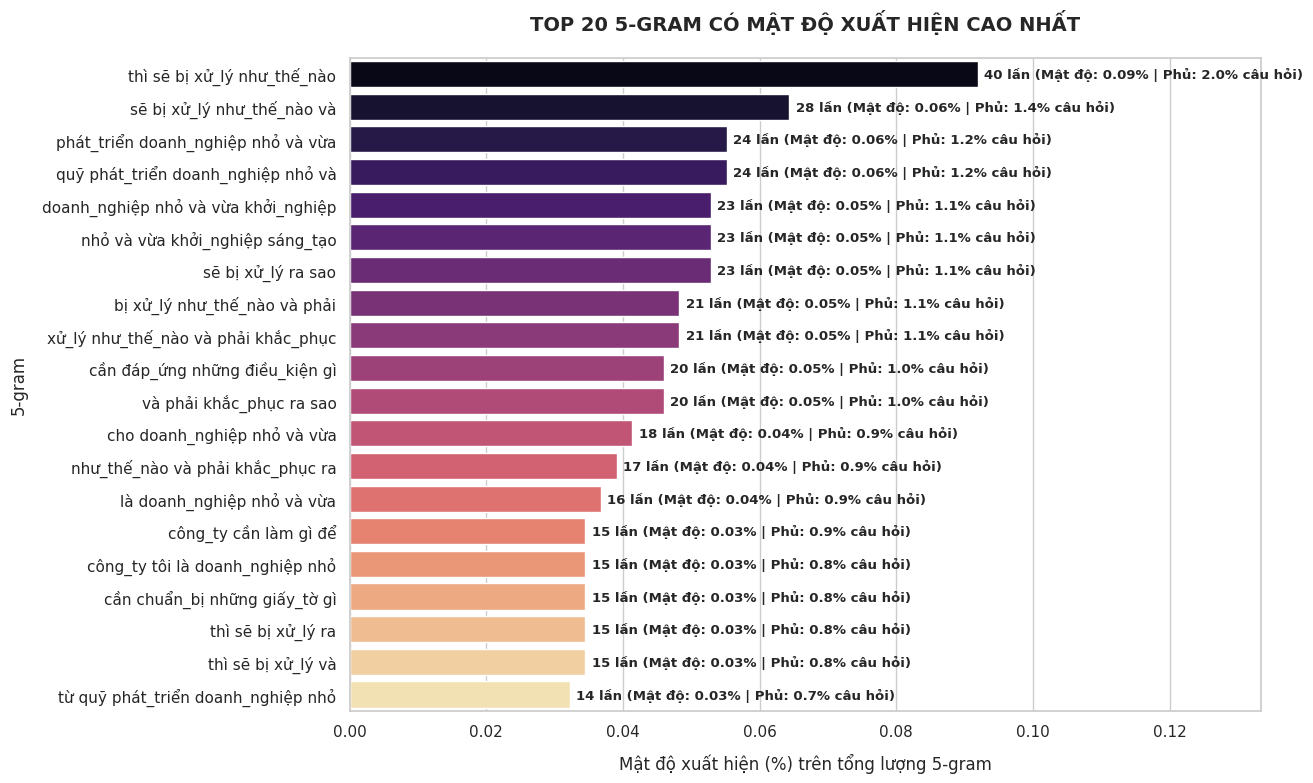

In [60]:
analyze_ngram(df, n=4, palette='magma')
analyze_ngram(df, n=5, palette='magma')